In [1]:
from pathlib import Path
import csv

path = Path('weather_data/sitka_weather_07-2021_simple.csv')
lines = path.read_text().splitlines()

reader = csv.reader(lines)  # Makes an reader object
header_row = next(reader)   # next() moves to the next string in the list

# To print the column header and their respective indexes
for index, column_header in enumerate(header_row):
    print(index, column_header)

0 STATION
1 NAME
2 DATE
3 TAVG
4 TMAX
5 TMIN


In [2]:
from pathlib import Path
import csv

path = Path('weather_data/sitka_weather_07-2021_simple.csv')
lines = path.read_text().splitlines()

reader = csv.reader(lines)  # Makes an reader object
header_row = next(reader)   # next() moves to the next string in the list

# Extract high temperatures
highs = []
for row in reader:
    high = int(row[4])
    highs.append(high)

print(highs)

[61, 60, 66, 60, 65, 59, 58, 58, 57, 60, 60, 60, 57, 58, 60, 61, 63, 63, 70, 64, 59, 63, 61, 58, 59, 64, 62, 70, 70, 73, 66]


[61, 60, 66, 60, 65, 59, 58, 58, 57, 60, 60, 60, 57, 58, 60, 61, 63, 63, 70, 64, 59, 63, 61, 58, 59, 64, 62, 70, 70, 73, 66]


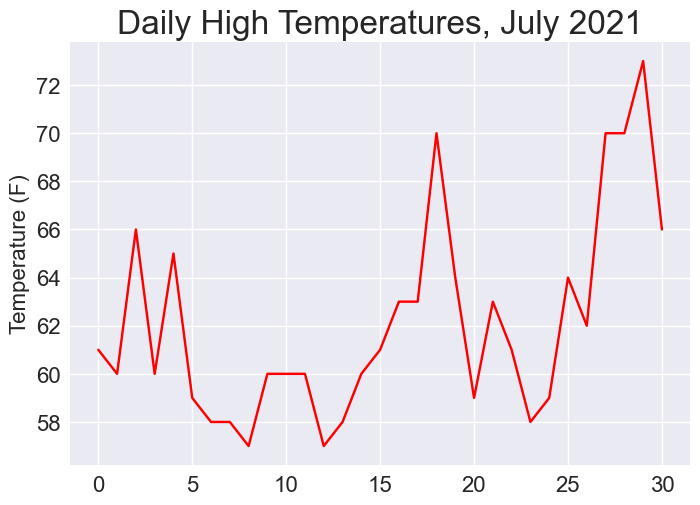

In [3]:
"""Plot a temperature graph with temperature values in the file"""
from pathlib import Path
import matplotlib.pyplot as plt
import csv

path = Path('weather_data/sitka_weather_07-2021_simple.csv')
lines = path.read_text().splitlines()

reader = csv.reader(lines)  # Makes an reader object
header_row = next(reader)   # next() moves to the next string in the list

# Extract high temperatures
# highs = []
# for row in reader:
#     high = int(row[4])
#     highs.append(high)
# list comprehension for 'for' loop
highs = [int(row[4]) for row in reader]

print(highs)

# Plot the high temperatures
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots()
ax.plot(highs, color='red')

# Format plot
ax.set_title("Daily High Temperatures, July 2021", fontsize=24)
ax.set_xlabel('', fontsize=16)
ax.set_ylabel("Temperature (F)", fontsize=16)
ax.tick_params(labelsize=16)
plt.show()

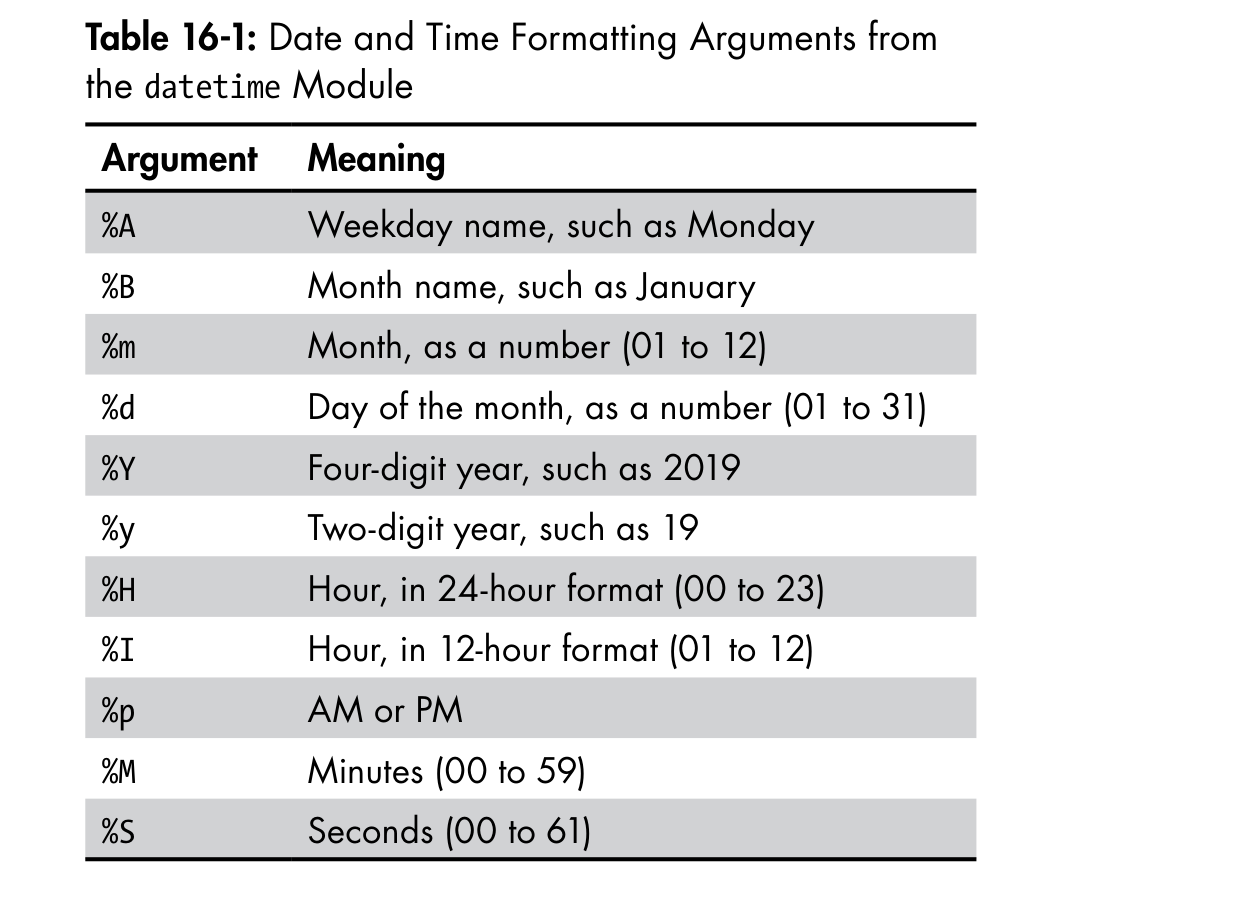

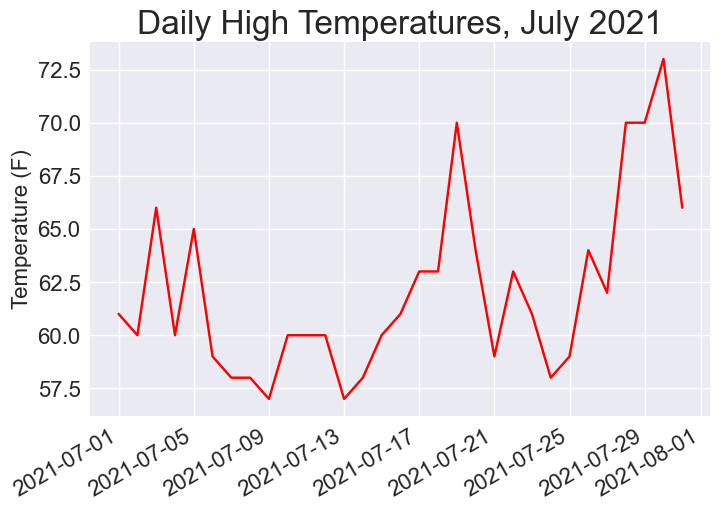

In [4]:
"""Plotting Dates"""

from pathlib import Path
import matplotlib.pyplot as plt
from datetime import datetime

import csv

path = Path('weather_data/sitka_weather_07-2021_simple.csv')
lines = path.read_text().splitlines()

reader = csv.reader(lines)  # Makes an reader object
header_row = next(reader)   # next() moves to the next string in the list

# Extract dates and high temperatures
dates, highs = [], []
for row in reader:
    current_date = datetime.strptime(row[2],'%Y-%m-%d')
    high = int(row[4])
    dates.append(current_date)
    highs.append(high)


# Plot the high temperatures
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots()
ax.plot(dates, highs, color='red')

# Format plot
ax.set_title("Daily High Temperatures, July 2021", fontsize=24)
ax.set_xlabel('', fontsize=16)
fig.autofmt_xdate()
ax.set_ylabel("Temperature (F)", fontsize=16)
ax.tick_params(labelsize=16)
plt.show()

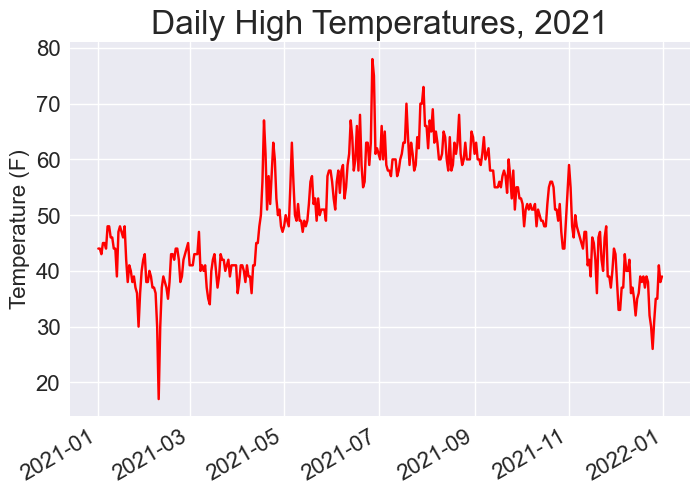

In [5]:
"""Plot for whole year's data"""

from pathlib import Path
import matplotlib.pyplot as plt
from datetime import datetime

import csv

path = Path('weather_data/sitka_weather_2021_simple.csv')
lines = path.read_text().splitlines()

reader = csv.reader(lines)  # Makes an reader object
header_row = next(reader)   # next() moves to the next string in the list

# Extract dates and high temperatures
dates, highs = [], []
for row in reader:
    current_date = datetime.strptime(row[2],'%Y-%m-%d')
    high = int(row[4])
    dates.append(current_date)
    highs.append(high)


# Plot the high temperatures
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots()
ax.plot(dates, highs, color='red')

# Format plot
ax.set_title("Daily High Temperatures, 2021", fontsize=24)
ax.set_xlabel('', fontsize=16)
fig.autofmt_xdate()
ax.set_ylabel("Temperature (F)", fontsize=16)
ax.tick_params(labelsize=16)
plt.show()


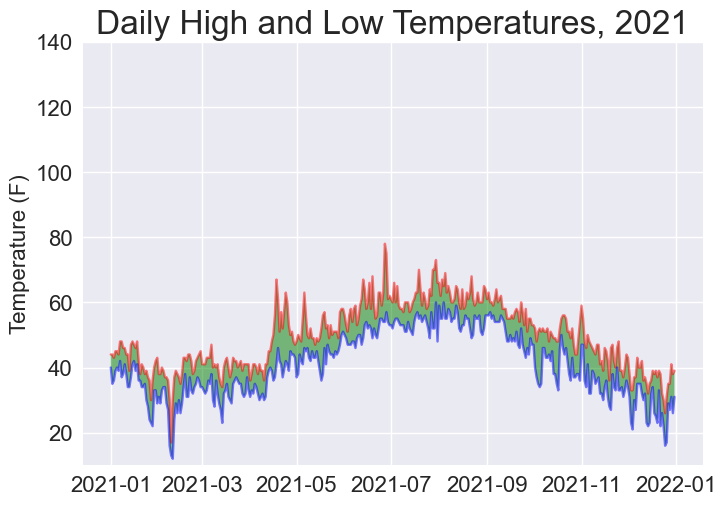

In [6]:
"""Plot a second data series including low temperatures in our previous graph"""

from pathlib import Path
import matplotlib.pyplot as plt
from datetime import datetime

import csv

path = Path('weather_data/sitka_weather_2021_simple.csv')
lines = path.read_text().splitlines()

reader = csv.reader(lines)  # Makes an reader object
header_row = next(reader)   # next() moves to the next string in the list

# Extract dates, low and high temperatures
dates, highs, lows = [], [], []
for row in reader:
    current_date = datetime.strptime(row[2],'%Y-%m-%d')
    high = int(row[4])
    low = int(row[5])
    dates.append(current_date)
    highs.append(high)
    lows.append(low)


# Plot the high and low temperatures
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots()
ax.plot(dates, highs, color='red', alpha=0.5)
ax.plot(dates, lows, color='blue', alpha=0.5)
ax.fill_between(dates, highs, lows, facecolor='green', alpha=0.5)

# Format plot
ax.set_title("Daily High and Low Temperatures, 2021", fontsize=24)
ax.set_xlabel('', fontsize=16)
ax.set_ylabel("Temperature (F)", fontsize=16)
ax.tick_params(labelsize=16)
ax.set_ylim([10, 140])
plt.show()

Missing date for 2021-05-04 00:00:00


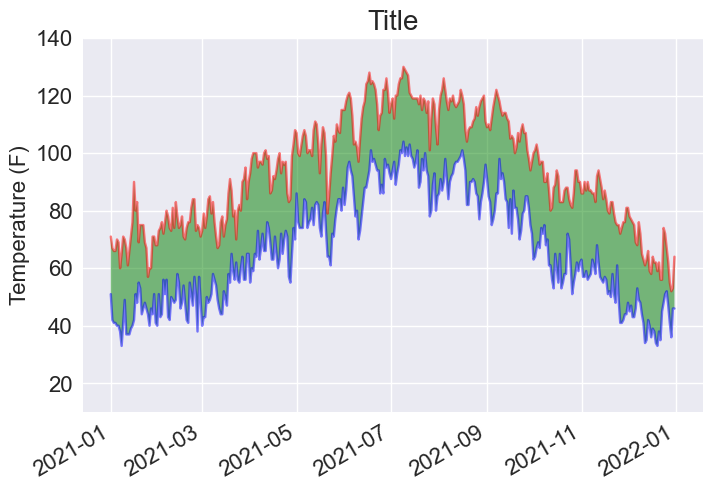

In [7]:
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import csv

path = Path('weather_data/death_valley_2021_simple.csv')
lines = path.read_text().splitlines()

reader = csv.reader(lines)
header_row = next(reader)

# Extract dates, low and high temperatures
dates, highs, lows = [], [], []
for row in reader:
    current_date = datetime.strptime(row[2],'%Y-%m-%d')
    try:
        high = int(row[3])
        low = int(row[4])
    except ValueError:
        print(f"Missing date for {current_date}")
    else:
        dates.append(current_date)
        highs.append(high)
        lows.append(low)


# Plot the high and low temperatures
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots()
ax.plot(dates, highs, color='red', alpha=0.5)
ax.plot(dates, lows, color='blue', alpha=0.5)
ax.fill_between(dates, highs, lows, facecolor='green', alpha=0.5)
ax.set_ylim([10, 140])

# Format plot
title = "Daily High and Low Temperatures, 2021\nDeath Valley, CA"
ax.set_title("Title", fontsize=20)
ax.set_xlabel('', fontsize=16)
fig.autofmt_xdate()
ax.set_ylabel("Temperature (F)", fontsize=16)
ax.tick_params(labelsize=16)

plt.show()